<a href="https://colab.research.google.com/github/gap1070/cs417-labs/blob/main/Lab12/notebooks/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 12: Breaking the O(n^2) Barrier — Analysis
In this notebook you'll visualize how advanced sorting algorithms work, measure their performance against the simple sorts from Lab 11, and discover quicksort's weakness.

Before you start: Paste your completed sort functions into the cell below.

In [1]:
def _gap_insertion_sort(a_list, start, gap):
    for i in range(start + gap, len(a_list), gap):
        current_value = a_list[i]
        position = i

        while position >= gap and a_list[position - gap] > current_value:
            a_list[position] = a_list[position - gap]
            position = position - gap

        a_list[position] = current_value


def shell_sort(a_list):
    gap = len(a_list) // 2
    while gap > 0:
        for start_position in range(gap):
            _gap_insertion_sort(a_list, start_position, gap)
        gap = gap // 2
    return a_list


def merge_sort(a_list):
    if len(a_list) <= 1:
        return a_list

    mid = len(a_list) // 2
    left = a_list[:mid]
    right = a_list[mid:]

    merge_sort(left)
    merge_sort(right)

    i = 0
    j = 0
    k = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            a_list[k] = left[i]
            i += 1
        else:
            a_list[k] = right[j]
            j += 1
        k += 1

    while i < len(left):
        a_list[k] = left[i]
        i += 1
        k += 1

    while j < len(right):
        a_list[k] = right[j]
        j += 1
        k += 1

    return a_list


def _partition(a_list, first, last):
    pivot_value = a_list[first]

    left_mark = first + 1
    right_mark = last
    done = False

    while not done:

        while left_mark <= right_mark and a_list[left_mark] <= pivot_value:
            left_mark += 1

        while left_mark <= right_mark and a_list[right_mark] >= pivot_value:
            right_mark -= 1

        if right_mark < left_mark:
            done = True
        else:
             a_list[left_mark], a_list[right_mark] = a_list[right_mark], a_list[left_mark]

    a_list[first], a_list[right_mark] = a_list[right_mark], a_list[first]

    return right_mark


def _quick_sort_helper(a_list, first, last):
    if first < last:
        split_point = _partition(a_list, first, last)
        _quick_sort_helper(a_list, first, split_point - 1)
        _quick_sort_helper(a_list, split_point + 1, last)


def quick_sort(a_list):
    if len(a_list) > 1:
        _quick_sort_helper(a_list, 0, len(a_list) - 1)
    return a_list


def merge_sort_counted(a_list):
    counts = [0, 0]

    def _merge_sort(lst):
        if len(lst) > 1:
            mid = len(lst) // 2
            left = lst[:mid]
            right = lst[mid:]
            _merge_sort(left)
            _merge_sort(right)
            i = j = k = 0
            while i < len(left) and j < len(right):
                counts[0] += 1
                if left[i] <= right[j]:
                    lst[k] = left[i]
                    i += 1
                else:
                    lst[k] = right[j]
                    j += 1
                counts[1] += 1
                k += 1
            while i < len(left):
                lst[k] = left[i]
                counts[1] += 1
                i += 1
                k += 1
            while j < len(right):
                lst[k] = right[j]
                counts[1] += 1
                j += 1
                k += 1

    _merge_sort(a_list)
    return (a_list, counts[0], counts[1])


def quick_sort_counted(a_list):
    counts = [0, 0]

    def _partition(lst, first, last):
        pivot_value = lst[first]
        left_mark = first + 1
        right_mark = last
        done = False
        while not done:
            while left_mark <= right_mark and lst[left_mark] <= pivot_value:
                counts[0] += 1
                left_mark += 1
            while left_mark <= right_mark and lst[right_mark] >= pivot_value:
                counts[0] += 1
                right_mark -= 1
            if right_mark < left_mark:
                done = True
            else:
                lst[left_mark], lst[right_mark] = lst[right_mark], lst[left_mark]
                counts[1] += 1
        lst[first], lst[right_mark] = lst[right_mark], lst[first]
        counts[1] += 1
        return right_mark

    def _qs(lst, first, last):
        if first < last:
            sp = _partition(lst, first, last)
            _qs(lst, first, sp - 1)
            _qs(lst, sp + 1, last)

    if len(a_list) > 1:
        _qs(a_list, 0, len(a_list) - 1)
    return (a_list, counts[0], counts[1])

In [2]:
# Quick sanity check — run this to make sure your functions work
assert shell_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "shell_sort failed"
assert merge_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "merge_sort failed"
assert quick_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "quick_sort failed"

r1, c1, m1 = merge_sort_counted([3, 1, 2])
assert r1 == [1, 2, 3], "merge_sort_counted failed"

r2, c2, e2 = quick_sort_counted([3, 1, 2])
assert r2 == [1, 2, 3], "quick_sort_counted failed"

print("All functions working!")

All functions working!


Experiment 1: Watching the Mechanism
Before we measure performance, let's see how each algorithm sorts. The helper functions below print the list state at key moments so you can watch the progress.

In [3]:
def shell_sort_visual(a_list):
    """Shell sort with printout after each gap pass."""
    a_list = a_list[:]
    n = len(a_list)
    gap = n // 2
    print(f"Start:    {a_list}  (n={n})")
    while gap > 0:
        for start in range(gap):
            for i in range(start + gap, n, gap):
                val = a_list[i]
                pos = i
                while pos >= gap and a_list[pos - gap] > val:
                    a_list[pos] = a_list[pos - gap]
                    pos -= gap
                a_list[pos] = val
        print(f"Gap {gap:>2}:   {a_list}")
        gap //= 2
    return a_list


def merge_sort_visual(a_list, depth=0):
    """Merge sort with printout showing split and merge at each level."""
    indent = "  " * depth
    if len(a_list) <= 1:
        return a_list
    mid = len(a_list) // 2
    print(f"{indent}Split: {a_list} -> {a_list[:mid]} + {a_list[mid:]}")
    left = merge_sort_visual(a_list[:mid], depth + 1)
    right = merge_sort_visual(a_list[mid:], depth + 1)
    # merge
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    print(f"{indent}Merge: {left} + {right} -> {result}")
    return result


def quick_sort_visual(a_list):
    """Quicksort with printout showing each partition result."""
    a_list = a_list[:]
    def _qs(lst, first, last):
        if first < last:
            piv = lst[first]
            lm, rm = first + 1, last
            done = False
            while not done:
                while lm <= rm and lst[lm] <= piv: lm += 1
                while lm <= rm and lst[rm] >= piv: rm -= 1
                if rm < lm: done = True
                else: lst[lm], lst[rm] = lst[rm], lst[lm]
            lst[first], lst[rm] = lst[rm], lst[first]
            print(f"  Pivot {piv:>2} -> final index {rm}: {lst}")
            _qs(lst, first, rm - 1)
            _qs(lst, rm + 1, last)
    print(f"Start: {a_list}")
    _qs(a_list, 0, len(a_list) - 1)
    return a_list

In [4]:
test_list = [54, 26, 93, 17, 77, 31, 44, 55, 20]

print("=" * 55)
print("SHELL SORT")
print("=" * 55)
shell_sort_visual(test_list)

print()
print("=" * 55)
print("MERGE SORT")
print("=" * 55)
merge_sort_visual(test_list)

print()
print("=" * 55)
print("QUICKSORT")
print("=" * 55)
quick_sort_visual(test_list)

SHELL SORT
Start:    [54, 26, 93, 17, 77, 31, 44, 55, 20]  (n=9)
Gap  4:   [20, 26, 44, 17, 54, 31, 93, 55, 77]
Gap  2:   [20, 17, 44, 26, 54, 31, 77, 55, 93]
Gap  1:   [17, 20, 26, 31, 44, 54, 55, 77, 93]

MERGE SORT
Split: [54, 26, 93, 17, 77, 31, 44, 55, 20] -> [54, 26, 93, 17] + [77, 31, 44, 55, 20]
  Split: [54, 26, 93, 17] -> [54, 26] + [93, 17]
    Split: [54, 26] -> [54] + [26]
    Merge: [54] + [26] -> [26, 54]
    Split: [93, 17] -> [93] + [17]
    Merge: [93] + [17] -> [17, 93]
  Merge: [26, 54] + [17, 93] -> [17, 26, 54, 93]
  Split: [77, 31, 44, 55, 20] -> [77, 31] + [44, 55, 20]
    Split: [77, 31] -> [77] + [31]
    Merge: [77] + [31] -> [31, 77]
    Split: [44, 55, 20] -> [44] + [55, 20]
      Split: [55, 20] -> [55] + [20]
      Merge: [55] + [20] -> [20, 55]
    Merge: [44] + [20, 55] -> [20, 44, 55]
  Merge: [31, 77] + [20, 44, 55] -> [20, 31, 44, 55, 77]
Merge: [17, 26, 54, 93] + [20, 31, 44, 55, 77] -> [17, 20, 26, 31, 44, 54, 55, 77, 93]

QUICKSORT
Start: [54, 26,

[17, 20, 26, 31, 44, 54, 55, 77, 93]

Experiment 1 Questions
Study the output above and answer these questions:

Q1: In shell sort, look at the list after the first gap pass vs. after the last. Is it fully sorted before gap = 1, or just "closer to sorted"? What does that tell you about what the gap = 1 pass has to do?

Your answer: After the first gap pass shell sort is not fully sorted. Then after gap pass of 4 and 2 happened, this list became closer to being sorted but it still wasnt completely sorted. The finally gap pass 1 did a regular insertion sort, which finishes the almost sorted list to fully sorted list.

Q2: In merge sort, how many levels of splitting happen for 9 items? Does the merge step at each level touch every item in that subproblem?

Your answer: When there are 9 items, merge sorts takes the list and splits it into 4 levels until each lists has a size of 1. At each of the 4 levels the items go into, the step when they merge happens and then two halves are the combined back together.

Q3: In quicksort, how many items are permanently placed after each partition call? How is this different from merge sort, where items only reach their final positions at the very end?

Your answer: In quicksort, the pivot elemnt is placed in its final sorting position after each partition occurs. From the output of the code we can see the pivots like 54, and 17 being placed in their final position. This is different from merge sort because in merge sort items are only placed in their final sorting positions at the end of the sort durin gthe last merge.

Experiment 2: Breaking the Barrier
This is the big moment. We'll run the simple O(n^2) sorts from Lab 11 alongside your Lab 12 sorts and watch the curves diverge.

The bubble sort and insertion sort counted versions are provided below so the notebook is self-contained — you don't need your Lab 11 code.

In [6]:
# ── Lab 11 sorts (provided for comparison) ───────────────────────

def bubble_sort_counted(a_list):
    """Bubble sort with comparison and exchange counting."""
    comparisons = 0
    exchanges = 0
    for i in range(len(a_list) - 1):
        for j in range(len(a_list) - 1 - i):
            comparisons += 1
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]
                exchanges += 1
    return (a_list, comparisons, exchanges)


def insertion_sort_counted(a_list):
    """Insertion sort with comparison and data-move counting."""
    comparisons = 0
    data_moves = 0
    for i in range(1, len(a_list)):
        current_value = a_list[i]
        position = i - 1
        while position >= 0 and a_list[position] > current_value:
            comparisons += 1
            a_list[position + 1] = a_list[position]
            data_moves += 1
            position -= 1
        if position >= 0:
            comparisons += 1  # the comparison that ended the while
        a_list[position + 1] = current_value
        data_moves += 1
    return (a_list, comparisons, data_moves)

In [7]:
import random
import matplotlib.pyplot as plt

sizes = [100, 500, 1000, 5000, 10000]

# Storage for results
results = {name: {"comps": [], "moves": []} for name in
           ["Bubble", "Insertion", "Merge", "Quick"]}

for n in sizes:
    data = list(range(n))
    random.shuffle(data)

    _, bc, be = bubble_sort_counted(data[:])
    _, ic, im = insertion_sort_counted(data[:])
    _, mc, mm = merge_sort_counted(data[:])
    _, qc, qe = quick_sort_counted(data[:])

    results["Bubble"]["comps"].append(bc)
    results["Bubble"]["moves"].append(be)
    results["Insertion"]["comps"].append(ic)
    results["Insertion"]["moves"].append(im)
    results["Merge"]["comps"].append(mc)
    results["Merge"]["moves"].append(mm)
    results["Quick"]["comps"].append(qc)
    results["Quick"]["moves"].append(qe)

    print(f"n={n:>6}: Bubble={bc:>12,}  Insertion={ic:>12,}  Merge={mc:>12,}  Quick={qc:>12,}")

n=   100: Bubble=       4,950  Insertion=       2,611  Merge=         546  Quick=         715
n=   500: Bubble=     124,750  Insertion=      62,051  Merge=       3,847  Quick=       4,607
n=  1000: Bubble=     499,500  Insertion=     255,345  Merge=       8,692  Quick=      10,204
n=  5000: Bubble=  12,497,500  Insertion=   6,281,896  Merge=      55,232  Quick=      67,298
n= 10000: Bubble=  49,995,000  Insertion=  24,842,080  Merge=     120,401  Quick=     150,712


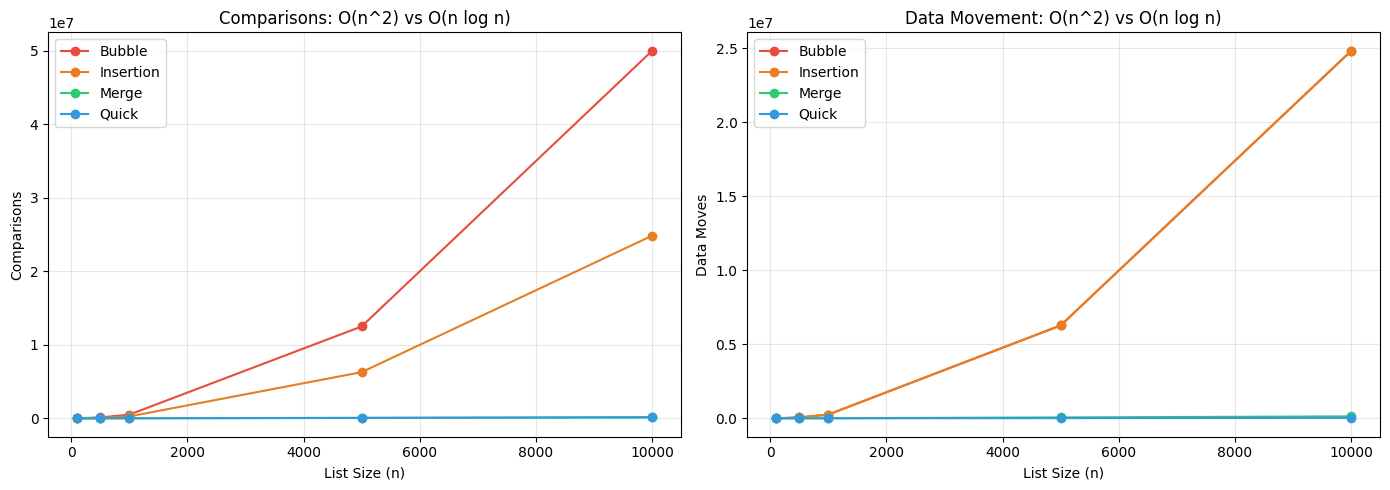

In [8]:
colors = {"Bubble": "#e74c3c", "Insertion": "#e67e22",
          "Merge": "#2ecc71", "Quick": "#3498db"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Comparisons
for name in results:
    ax1.plot(sizes, results[name]["comps"], 'o-',
             label=name, color=colors[name])
ax1.set_xlabel('List Size (n)')
ax1.set_ylabel('Comparisons')
ax1.set_title('Comparisons: O(n^2) vs O(n log n)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Data moves
for name in results:
    ax2.plot(sizes, results[name]["moves"], 'o-',
             label=name, color=colors[name])
ax2.set_xlabel('List Size (n)')
ax2.set_ylabel('Data Moves')
ax2.set_title('Data Movement: O(n^2) vs O(n log n)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Experiment 2 Questions
Q1: At what list size do the O(n^2) and O(n log n) curves visibly diverge? Is the separation gradual or does it suddenly explode?

Your answer: The curve starts to visibly diverge at around 1,000 elements, and from there the difference just keeps getting greater between them. At 10,000 elmements they are all very dofferent about of comparisons.

Q2: At n = 10,000, roughly how many times more comparisons does bubble sort make than merge sort? Than quicksort?

Your answer: At n = 10,000, bubble sort makes around 50 million comparions, and merge and quicksort make around 120k to 150k comparisons. That means bubble sort roughly does 400 times more comparisons than merge and quicksort.

Q3: Shell sort isn't shown on this graph (it doesn't have a counted version). Based on what you know about its complexity — between O(n) and O(n^2) — where would you expect it to fall? Closer to the red/orange lines or the green/blue lines?

Your answer: I would say shell sort would probably fall between the O(n^2) and O(n log n) alrogithms. But between those I would say it woul dbe closer to merge sort and quicksort.

Experiment 3: Quicksort's Achilles Heel
Merge sort is O(n log n) in all cases. Quicksort is O(n log n) on average but O(n^2) in the worst case. Let's find that worst case.

In [10]:
import sys
sys.setrecursionlimit(2000)

n = 1000

already_sorted = list(range(n))
reverse_sorted = list(range(n - 1, -1, -1))
random_list = list(range(n))
random.shuffle(random_list)

cases = {
    "Already sorted": already_sorted,
    "Reverse sorted": reverse_sorted,
    "Random": random_list,
}

print(f"{'Case':<20} {'Algorithm':<12} {'Comparisons':>12} {'Data Moves':>12}")
print("-" * 60)

for case_name, data in cases.items():
    _, mc, mm = merge_sort_counted(data[:])
    _, qc, qe = quick_sort_counted(data[:])
    print(f"{case_name:<20} {'Merge':<12} {mc:>12,} {mm:>12,}")
    print(f"{'':<20} {'Quick':<12} {qc:>12,} {qe:>12,}")
    if case_name != "Random":
        print()
    else:
        print()


Case                 Algorithm     Comparisons   Data Moves
------------------------------------------------------------
Already sorted       Merge               4,932        9,976
                     Quick             499,500          999

Reverse sorted       Merge               5,044        9,976
                     Quick             499,500          999

Random               Merge               8,731        9,976
                     Quick              10,892        2,376



Experiment 3 Questions
Q1: On random input, which makes fewer comparisons — merge sort or quicksort? Are they in the same ballpark?

Your answer: For a random input, merge sort makes less comparisons but only by like 2,000 less. Merge sort also uses around 7,000 more data moves though.

Q2: On already-sorted input, what happens to quicksort's comparison count compared to random input? How does it compare to merge sort on the same input?

Your answer: For an already sorted input, quicksort comparisons goes up alot to almost 500,000 comparisons. Compares to merge sorts 5,000 comparisons, thats like 10,000x more comparisons.

Q3: Why does sorted input cause quicksort's worst case? Think about what happens when the pivot (first item) is always the smallest value — what do the partitions look like? How many levels of recursion do you get?

Your answer: An already sorted input causes quicksorts worst case because of the pivot. It is alsways the smallest item, which then creates an uneven partitions. This leads to it perfoming so many comparisons nd having to do many recursions.

Q4: Given this weakness, why would anyone use quicksort instead of merge sort? Think about the data moves column — what does "in-place" mean for memory when sorting a list of 10 million items?

Your answer: I think people would maybe use quicksort because of how much memory it uses. In the tests above quicksort did so many more comparions than merge and it somehow still had alot less data moves. When you have a very large list and use merge sort then you will use alot of memory. But for quicksort it might take longer but it uses so much less data moves.